<a href="https://colab.research.google.com/github/anitahf/Clase---Aprendizaje-Automatico/blob/main/A_H_08_Arboles_Decision.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

<a href="https://colab.research.google.com/github/andres-merino/AprendizajeAutomaticoInicial-05-N0105/blob/main/2-Ejercicios/08-Arboles-Decision.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

<table style="border: none; border-collapse: collapse;">
    <tr>
        <td style="width: 20%; vertical-align: middle; padding-right: 10px;">
            <img src="https://i.imgur.com/nt7hloA.png" width="100">
        </td>
        <td style="width: 2px; text-align: center;">
            <font color="#0030A1" size="7">|</font><br>
            <font color="#0030A1" size="7">|</font>
        </td>
        <td>
            <p style="font-variant: small-caps;"><font color="#0030A1" size="5">
                <b>Facultad de Ciencias Exactas, Naturales y Ambientales</b>
            </font> </p>
            <p style="font-variant: small-caps;"><font color="#0030A1" size="4">
                Aprendizaje Automático Inicial &bull; Árboles de Decisión
            </font></p>
            <p style="font-style: oblique;"><font color="#0030A1" size="3">
                Anita Hidalgo &bull; 2025-04
            </font></p>
        </td>  
    </tr>
</table>

---
## <font color='264CC7'> Introducción </font>

A lo largo de este taller, aplicaremos un perceptrón para clasificar un conjunto de datos.

Los paquetes necesarios son:

In [ ]:
# Paquetes necesarios
from sklearn.datasets import fetch_openml
import pandas as pd  # Manejo de datos
import matplotlib.pyplot as plt  # Visualización

from sklearn.model_selection import train_test_split # División de datos
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report  # Métrica de evaluación

from sklearn.datasets import load_iris
from sklearn.tree import DecisionTreeClassifier, plot_tree
from sklearn.linear_model import Perceptron

---
## <font color='264CC7'> Clasificación </font>


### <font color='264CC7'> Preprocesamiento de datos </font>

Primero necesitas el conjunto de datos. Los datos a utilzar son los seleccionados en la clase anterior.

<div style="background-color: #edf1f8; border-color: #264CC7; border-left: 5px solid #264CC7; padding: 0.5em;">
<strong>Ejercicio:</strong><br>
    Carga el conjunto de datos y procésalos:
<ul>
  <li>Muestra algunos datos.</li>
  <li>Muestra una descripción de los datos.</li>
  <li>Escala los datos si es necesario.</li>
</ul>
</div>

In [ ]:
# Cargar el dataset desde GitHub
url = "https://raw.githubusercontent.com/anitahf/Clase---Aprendizaje-Automatico/main/dataset.csv"
data = pd.read_csv(url)

In [ ]:
data.head()

,Unnamed: 0,track_id,artists,album_name,track_name,popularity,duration_ms,explicit,danceability,energy,...,loudness,mode,speechiness,acousticness,instrumentalness,liveness,valence,tempo,time_signature,track_genre
0,0,5SuOikwiRyPMVoIQDJUgSV,Gen Hoshino,Comedy,Comedy,73,230666,False,0.676,0.4610,...,-6.746,0,0.1430,0.0322,0.000001,0.3580,0.715,87.917,4,acoustic
1,1,4qPNDBW1i3p13qLCt0Ki3A,Ben Woodward,Ghost (Acoustic),Ghost - Acoustic,55,149610,False,0.420,0.1660,...,-17.235,1,0.0763,0.9240,0.000006,0.1010,0.267,77.489,4,acoustic
2,2,1iJBSr7s7jYXzM8EGcbK5b,Ingrid Michaelson;ZAYN,To Begin Again,To Begin Again,57,210826,False,0.438,0.3590,...,-9.734,1,0.0557,0.2100,0.000000,0.1170,0.120,76.332,4,acoustic
3,3,6lfxq3CG4xtTiEg7opyCyx,Kina Grannis,Crazy Rich Asians (Original Motion Picture Sou...,Can't Help Falling In Love,71,201933,False,0.266,0.0596,...,-18.515,1,0.0363,0.9050,0.000071,0.1320,0.143,181.740,3,acoustic
4,4,5vjLSffimiIP26QG5WcN2K,Chord Overstreet,Hold On,Hold On,82,198853,False,0.618,0.4430,...,-9.681,1,0.0526,0.4690,0.000000,0.0829,0.167,119.949,4,acoustic


In [ ]:
data.dtypes

,0
Unnamed: 0,int64
track_id,object
artists,object
album_name,object
track_name,object
popularity,int64
duration_ms,int64
explicit,bool
danceability,float64
energy,float64


In [ ]:
data.describe()

,Unnamed: 0,popularity,duration_ms,danceability,energy,key,loudness,mode,speechiness,acousticness,instrumentalness,liveness,valence,tempo,time_signature
count,114000.000000,114000.000000,1.140000e+05,114000.000000,114000.000000,114000.000000,114000.000000,114000.000000,114000.000000,114000.000000,114000.000000,114000.000000,114000.000000,114000.000000,114000.000000
mean,56999.500000,33.238535,2.280292e+05,0.566800,0.641383,5.309140,-8.258960,0.637553,0.084652,0.314910,0.156050,0.213553,0.474068,122.147837,3.904035
std,32909.109681,22.305078,1.072977e+05,0.173542,0.251529,3.559987,5.029337,0.480709,0.105732,0.332523,0.309555,0.190378,0.259261,29.978197,0.432621
min,0.000000,0.000000,0.000000e+00,0.000000,0.000000,0.000000,-49.531000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,28499.750000,17.000000,1.740660e+05,0.456000,0.472000,2.000000,-10.013000,0.000000,0.035900,0.016900,0.000000,0.098000,0.260000,99.218750,4.000000
50%,56999.500000,35.000000,2.129060e+05,0.580000,0.685000,5.000000,-7.004000,1.000000,0.048900,0.169000,0.000042,0.132000,0.464000,122.017000,4.000000
75%,85499.250000,50.000000,2.615060e+05,0.695000,0.854000,8.000000,-5.003000,1.000000,0.084500,0.598000,0.049000,0.273000,0.683000,140.071000,4.000000
max,113999.000000,100.000000,5.237295e+06,0.985000,1.000000,11.000000,4.532000,1.000000,0.965000,0.996000,1.000000,1.000000,0.995000,243.372000,5.000000


In [ ]:
X = data.select_dtypes(include=['number'])
y = data.iloc[:, -1]

In [ ]:
y = y.astype(str)

In [ ]:
X = data.iloc[:, :-1]
y = data.iloc[:, -1]

In [ ]:
# Escalado
X = (X - X.min()) / (X.max() - X.min())


### <font color='264CC7'> Entrenamiento del modelo y evaluación </font>


<div style="background-color: #edf1f8; border-color: #264CC7; border-left: 5px solid #264CC7; padding: 0.5em;">
<strong>Ejercicio:</strong><br>
    Entrena el modelo y evalúalo:
<ul>
  <li>Entrena el modelo.</li>
  <li>Evalúa el modelo con el conjunto de datos de prueba.</li>
  <li>Genera una matriz de confusión y muestra las métricas de evaluación.</li>
</ul>
</div>

In [ ]:
# División en entrenamiento y prueba
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

In [ ]:
# Crear el modelo Perceptrón
modelo = Perceptron(max_iter=1000, random_state=42)

# Entrenar el modelo
modelo.fit(X_train, y_train)

Perceptron(random_state=42)

In [ ]:
# Predicciones sobre el conjunto de prueba
y_pred = modelo.predict(X_test)

In [ ]:
accuracy = accuracy_score(y_test, y_pred)
print("Precisión del modelo:", accuracy)

Precisión del modelo: 0.17241228070175438


In [ ]:
cm = confusion_matrix(y_test, y_pred)
print("Matriz de confusión:")
print(cm)

Matriz de confusión:
[[ 88  76   0 ...   0   0   0]
 [  0 189   0 ...   0   0   0]
 [  0  68   0 ...   0   0   0]
 ...
 [  0   0   0 ...  38  10   2]
 [  0   0   0 ...   1  39   0]
 [  0   0   0 ...   6   1  74]]


In [ ]:
print("Reporte de clasificación:")
print(classification_report(y_test, y_pred))

Reporte de clasificación:


/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


                   precision    recall  f1-score   support

         acoustic       0.98      0.41      0.58       213
         afrobeat       0.42      0.93      0.58       203
         alt-rock       0.00      0.00      0.00       215
      alternative       1.00      0.01      0.01       184
          ambient       0.77      0.55      0.64       197
            anime       0.45      0.05      0.08       193
      black-metal       0.94      0.07      0.13       210
        bluegrass       0.00      0.00      0.00       205
            blues       0.17      0.34      0.23       214
           brazil       0.00      0.00      0.00       197
        breakbeat       0.00      0.00      0.00       199
          british       0.00      0.00      0.00       214
         cantopop       0.38      0.21      0.27       193
    chicago-house       1.00      0.02      0.04       206
         children       0.72      0.08      0.15       214
            chill       0.35      0.22      0.27       

/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


In [ ]:
arbol = DecisionTreeClassifier(criterion="entropy", random_state=42)
arbol.fit(X_train, y_train)

DecisionTreeClassifier(criterion='entropy', random_state=42)

In [ ]:
y_pred = arbol.predict(X_test)

acc = accuracy_score(y_test, y_pred)
print("Precisión del modelo:", acc)

cm = confusion_matrix(y_test, y_pred)
print("Matriz de confusión:")
print(cm)

print("Reporte de clasificación:")
print(classification_report(y_test, y_pred))


Precisión del modelo: 0.9989912280701755
Matriz de confusión:
[[213   0   0 ...   0   0   0]
 [  0 203   0 ...   0   0   0]
 [  0   0 215 ...   0   0   0]
 ...
 [  0   0   0 ... 177   0   0]
 [  0   0   0 ...   0 183   0]
 [  0   0   0 ...   0   0 181]]
Reporte de clasificación:
                   precision    recall  f1-score   support

         acoustic       1.00      1.00      1.00       213
         afrobeat       1.00      1.00      1.00       203
         alt-rock       1.00      1.00      1.00       215
      alternative       1.00      1.00      1.00       184
          ambient       1.00      1.00      1.00       197
            anime       0.99      1.00      1.00       193
      black-metal       1.00      1.00      1.00       210
        bluegrass       1.00      1.00      1.00       205
            blues       1.00      1.00      1.00       214
           brazil       1.00      1.00      1.00       197
        breakbeat       0.99      1.00      1.00       199
          b

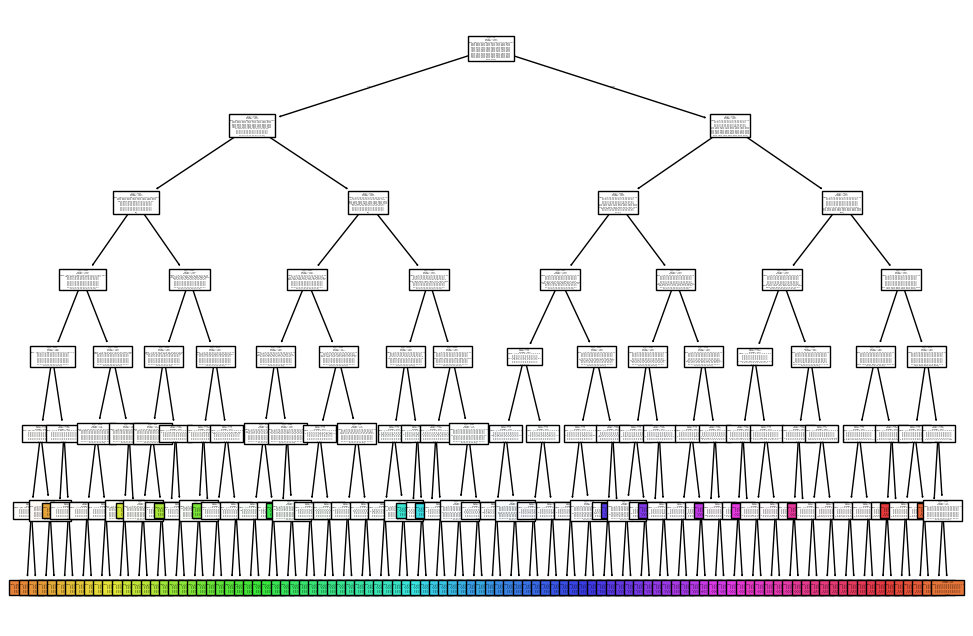

In [ ]:
plt.figure(figsize=(12, 8))
plot_tree(arbol, filled=True)
plt.show()

In [ ]:
#Limitare para que no se vea tan amontonado
arbol = DecisionTreeClassifier(
    criterion="entropy",
    max_depth=4,
    random_state=42
)

arbol.fit(X_train, y_train)

DecisionTreeClassifier(criterion='entropy', max_depth=4, random_state=42)

In [ ]:
y_pred = arbol.predict(X_test)

print("Precisión del modelo:", accuracy_score(y_test, y_pred))
print("Matriz de confusión:")
print(confusion_matrix(y_test, y_pred))
print("Reporte de clasificación:")
print(classification_report(y_test, y_pred))


Precisión del modelo: 0.1305701754385965
Matriz de confusión:
[[  0   0   0 ...   0   0   0]
 [  0   0   0 ...   0   0   0]
 [  0   0   0 ...   0   0   0]
 ...
 [  0   0   0 ... 177   0   0]
 [  0   0   0 ... 183   0   0]
 [  0   0   0 ... 181   0   0]]
Reporte de clasificación:


/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


                   precision    recall  f1-score   support

         acoustic       0.00      0.00      0.00       213
         afrobeat       0.00      0.00      0.00       203
         alt-rock       0.00      0.00      0.00       215
      alternative       0.13      1.00      0.23       184
          ambient       0.00      0.00      0.00       197
            anime       0.00      0.00      0.00       193
      black-metal       0.00      0.00      0.00       210
        bluegrass       0.00      0.00      0.00       205
            blues       0.00      0.00      0.00       214
           brazil       0.00      0.00      0.00       197
        breakbeat       0.00      0.00      0.00       199
          british       0.00      0.00      0.00       214
         cantopop       0.14      1.00      0.24       193
    chicago-house       0.00      0.00      0.00       206
         children       0.00      0.00      0.00       214
            chill       0.00      0.00      0.00       

/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


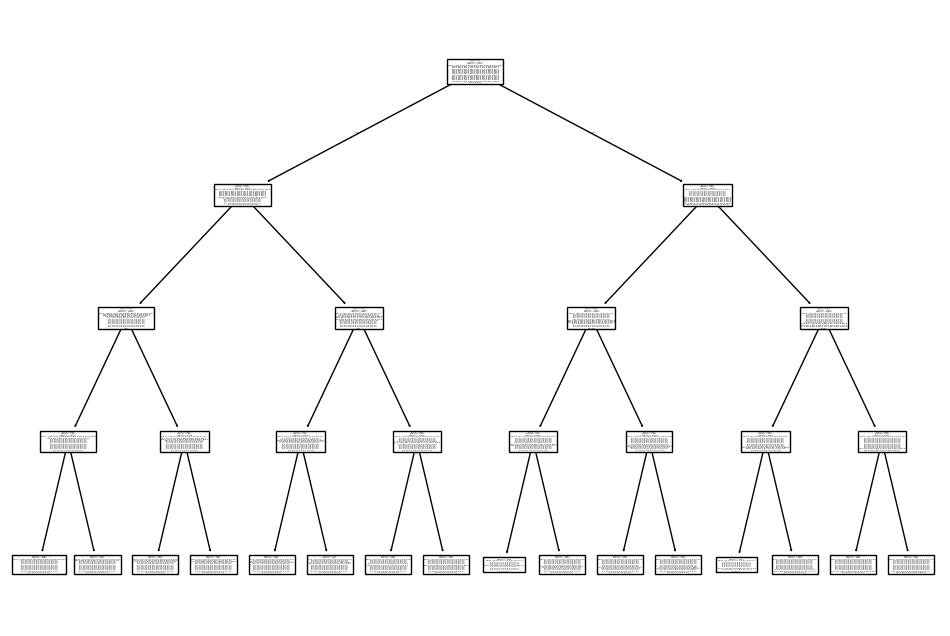

In [ ]:
plt.figure(figsize=(12, 8))
plot_tree(arbol, filled=True)
plt.show()

Conclusión

En este trabajo se aplicaron distintos modelos de clasificación para analizar el conjunto de datos. Primero se entrenó un perceptrón, lo que permitió tener una referencia inicial del desempeño del modelo. Luego se utilizó un árbol de decisión, con el cual se obtuvieron mejores resultados en términos de precisión.

Al analizar el árbol, se observó que cuando no se limita su profundidad el modelo tiende a sobreajustarse, logrando una precisión muy alta pero generando una estructura difícil de interpretar. Al limitar la profundidad, el árbol se vuelve más simple y fácil de entender, manteniendo un buen rendimiento.